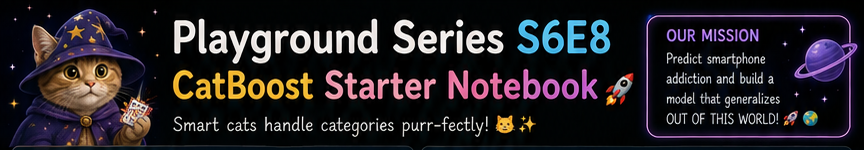

# 🐱 CatBoost Starter — Predicting Smartphone Addiction

Welcome to the **cat-powered sequel** in our S6E8 starter series! 🚀

We already tried a tree booster and a neural net. Now we meet a model with a superpower that is especially convenient for tabular data:

> **CatBoost can work with categorical columns directly.**

No one-hot explosion. No arbitrary integer codes pretending categories have an order. We tell CatBoost which columns are categorical and let the cat do the rest. 😺

In this notebook we will:

- engineer a small set of readable behavioral features,
- keep `gender`, `stress_level`, and `academic_work_impact` as **native categoricals**,
- train **5 stratified CatBoost folds** with early stopping,
- print validation AUC during boosting and after every fold,
- calculate the **overall OOF ROC AUC**,
- inspect CatBoost feature importance,
- save OOF predictions + fold metrics + importance,
- average five test predictions into `submission.csv`.

**Goal:** a starter that is strong enough to be useful, simple enough to learn from, and fun enough that we actually want to finish reading it. 🐾✨


# 1. Mission Map 🗺️

### 📂 Raw data → 🧪 smart features → 🐱 native categories → 🌳 CatBoost → 🎯 5 folds → 🏆 OOF AUC → 📊 importance → 🚀 submission

A few principles guide the notebook:

1. **Validation first.** Every training row receives exactly one out-of-fold prediction.
2. **No target leakage.** Feature engineering uses predictors only.
3. **Keep categories as categories.** That is the whole CatBoost party trick.
4. **Average fold test predictions.** Five slightly different models become a tiny ensemble for free.
5. **Save reusable artifacts.** Future-you can blend these OOF predictions with XGB, NN, LightGBM, etc.


# 2. Setup & Imports ⚙️

CatBoost is available in Kaggle's standard Python environment. The notebook uses CPU by default for maximum compatibility; set `USE_GPU=True` if your Kaggle notebook has a GPU attached.

`FAST_DEV_RUN` is only for debugging. Leave it `False` for a real CV run.


In [1]:
from pathlib import Path
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

from catboost import CatBoostClassifier, Pool
import catboost

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

SEED = 42
N_SPLITS = 5
TARGET = 'addicted_label'
ID_COL = 'id'

USE_GPU = False
VERBOSE_EVAL = 100
FAST_DEV_RUN = os.environ.get('CATBOOST_FAST_DEV_RUN', '0') == '1'

np.random.seed(SEED)

print('✅ Cat carrier loaded!')
print('CatBoost version:', catboost.__version__)
print('Mode:', 'FAST DEV RUN' if FAST_DEV_RUN else 'FULL CV RUN')
print('Task type:', 'GPU' if USE_GPU else 'CPU')


✅ Cat carrier loaded!
CatBoost version: 1.2.10
Mode: FULL CV RUN
Task type: CPU


# 3. Load the Competition Data 📂

The loader checks the official Kaggle competition path first, then a local directory. That makes the notebook convenient both on Kaggle and off Kaggle.


In [2]:
LOCAL_DATA_DIR = Path(os.environ.get('S6E8_DATA_DIR', '/mnt/data'))

candidate_dirs = [
    Path('/kaggle/input/playground-series-s6e8'),
    Path('/kaggle/input/competitions/playground-series-s6e8'),
    LOCAL_DATA_DIR,
]

DATA_DIR = None
for d in candidate_dirs:
    if (d / 'train.csv').exists() and (d / 'test.csv').exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find train.csv + test.csv. On Kaggle, attach the S6E8 competition data. '
        'Locally, set S6E8_DATA_DIR to the folder containing the competition files.'
    )

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

sample_path = DATA_DIR / 'sample_submission.csv'
sample_submission = pd.read_csv(sample_path) if sample_path.exists() else None

print('Data directory:', DATA_DIR)
print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Target mean:', f"{train[TARGET].mean():.4f}")

display(train.head())


Data directory: /kaggle/input/competitions/playground-series-s6e8
Train shape: (691369, 14)
Test shape : (296302, 13)
Target mean: 0.7094


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## Quick pre-flight checks ✈️

Before training, let's verify that train/test have the same raw predictors and look at missingness.

One important CatBoost detail:

- **numeric NaNs are fine** — CatBoost can learn how to route them through trees;
- **categorical NaNs should become an explicit string token**, such as `"(missing)"`.

That gives “missing category” its own identity instead of pretending it is a number.


In [3]:
raw_features = [c for c in train.columns if c not in [ID_COL, TARGET]]
assert TARGET in train.columns
assert TARGET not in test.columns
assert set(raw_features) == set(c for c in test.columns if c != ID_COL)
assert set(train[TARGET].dropna().unique()).issubset({0, 1})
assert train[ID_COL].is_unique and test[ID_COL].is_unique

summary = pd.DataFrame({
    'dtype': train[raw_features].dtypes.astype(str),
    'unique': train[raw_features].nunique(dropna=True),
    'missing_%': train[raw_features].isna().mean().mul(100),
}).sort_values('missing_%', ascending=False)

display(summary.style.format({'missing_%': '{:.2f}%'}))


,dtype,unique,missing_%
social_media_hours,float64,721,19.38%
gaming_hours,float64,401,18.34%
weekend_screen_time,float64,1437,16.21%
daily_screen_time_hours,float64,1389,13.86%
app_opens_per_day,float64,166,11.67%
notifications_per_day,float64,231,9.78%
stress_level,object,3,7.98%
work_study_hours,float64,600,7.45%
sleep_hours,float64,451,6.43%
academic_work_impact,object,2,6.40%


# 4. Why CatBoost? Explained With Cats 🐱🎩

Suppose a feature says someone's stress level is:

`Low`, `Medium`, or `High`.

A normal numeric model cannot eat those words. One common solution is **one-hot encoding**:

`stress_Low`, `stress_Medium`, `stress_High`.

CatBoost can skip that manual step. We simply say:

> “Hey CatBoost, this column is categorical.”

CatBoost then builds statistics from categories while carefully controlling how target information is used. One of its famous ideas is **ordered target statistics**: when creating category-related signals for a row, CatBoost tries to use information from rows that come *before* it in a randomized ordering instead of casually peeking at that row's own label.

### Fifth-grader version 🍪

Imagine predicting whether a kid likes cookies based on their favorite animal.

If you ask **the same kid** whether they like cookies and then use their answer to build their own feature, you cheated. 😼

CatBoost tries to learn category clues from **other kids first**, then use those clues for the current kid. That is why CatBoost became famous for categorical tabular data.


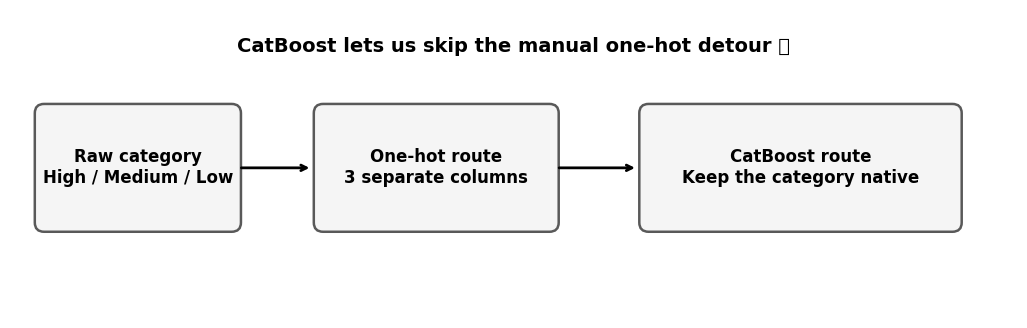

In [4]:
# Tiny visual: three ways to think about one categorical column.
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.4, 1.2, 2.5, 1.5, 'Raw category\nHigh / Medium / Low'),
    (4.0, 1.2, 3.0, 1.5, 'One-hot route\n3 separate columns'),
    (8.2, 1.2, 4.0, 1.5, 'CatBoost route\nKeep the category native'),
]
for x, y, w, h, label in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08,rounding_size=0.12',
                           linewidth=1.8, edgecolor='0.35', facecolor='0.96')
    ax.add_patch(patch)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center', fontsize=12, fontweight='bold')

ax.annotate('', xy=(3.9, 1.95), xytext=(2.95, 1.95), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(8.1, 1.95), xytext=(7.05, 1.95), arrowprops=dict(arrowstyle='->', lw=2))
ax.text(6.5, 3.45, 'CatBoost lets us skip the manual one-hot detour 🐾', ha='center', fontsize=14, fontweight='bold')
plt.show()


# 5. Basic Feature Engineering 🧪✨

We reuse the same human-readable feature ideas as the XGB and NN starters so model comparisons stay meaningful.

The EDA suggested a strong story around:

- total screen usage,
- how screen time is divided among social/gaming/work-study,
- weekend lift,
- screen vs sleep balance,
- engagement intensity,
- and whether several fields are missing at once.

The point is **not** to generate hundreds of mystery columns. These are deliberately readable features you could explain to another human.


In [5]:
CATEGORICAL_COLS = ['gender', 'stress_level', 'academic_work_impact']


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    return num / den.replace(0, np.nan)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # How much information is missing in this row?
    base_predictors = [c for c in out.columns if c != ID_COL]
    out['missing_count'] = out[base_predictors].isna().sum(axis=1).astype('float32')

    # Screen-time composition.
    component_cols = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    out['screen_component_total'] = out[component_cols].sum(axis=1, min_count=len(component_cols))
    out['time_accounting_residual'] = (
        out['daily_screen_time_hours']
        - out['social_media_hours']
        - out['gaming_hours']
        - out['work_study_hours']
    )
    out['weekend_lift'] = out['weekend_screen_time'] - out['daily_screen_time_hours']
    out['weekend_ratio'] = safe_divide(out['weekend_screen_time'], out['daily_screen_time_hours'])

    # Shares of total daily screen time.
    out['social_share_of_daily'] = safe_divide(out['social_media_hours'], out['daily_screen_time_hours'])
    out['gaming_share_of_daily'] = safe_divide(out['gaming_hours'], out['daily_screen_time_hours'])
    out['work_study_share_of_daily'] = safe_divide(out['work_study_hours'], out['daily_screen_time_hours'])

    # Sleep / screen balance.
    out['sleep_minus_screen'] = out['sleep_hours'] - out['daily_screen_time_hours']
    out['screen_to_sleep_ratio'] = safe_divide(out['daily_screen_time_hours'], out['sleep_hours'])

    # Engagement intensity.
    out['opens_per_screen_hour'] = safe_divide(out['app_opens_per_day'], out['daily_screen_time_hours'])
    out['notifications_per_screen_hour'] = safe_divide(out['notifications_per_day'], out['daily_screen_time_hours'])
    out['notifications_per_open'] = safe_divide(out['notifications_per_day'], out['app_opens_per_day'])
    out['engagement_events'] = out['notifications_per_day'] + out['app_opens_per_day']

    out = out.replace([np.inf, -np.inf], np.nan)

    # CatBoost categorical columns cannot contain numeric NaN values.
    # Give missing categories a real string label instead.
    for c in CATEGORICAL_COLS:
        if c in out.columns:
            out[c] = out[c].fillna('(missing)').astype(str)

    return out


train_fe = engineer_features(train.drop(columns=[TARGET]))
test_fe = engineer_features(test.copy())

train_ids = train[ID_COL].copy()
test_ids = test[ID_COL].copy()
y = train[TARGET].astype(np.int8).copy()

X = train_fe.drop(columns=[ID_COL]).reset_index(drop=True)
X_test = test_fe.drop(columns=[ID_COL]).reset_index(drop=True)

assert X.columns.equals(X_test.columns)
assert len(X) == len(y)

cat_features = [c for c in CATEGORICAL_COLS if c in X.columns]
num_features = [c for c in X.columns if c not in cat_features]

print('Raw predictors       :', len(raw_features))
print('Engineered predictors:', X.shape[1])
print('Numeric model columns:', len(num_features))
print('Native categoricals  :', cat_features)
print('No one-hot encoding! 😺')


Raw predictors       : 12
Engineered predictors: 26
Numeric model columns: 23
Native categoricals  : ['gender', 'stress_level', 'academic_work_impact']
No one-hot encoding! 😺


# 6. CatBoost Configuration 🌳🐈

This is a **starter configuration**, not a magic hyperparameter recipe.

A few knobs worth knowing:

- `iterations`: maximum number of boosting rounds.
- `learning_rate`: how cautiously each new tree updates the model.
- `depth`: tree complexity.
- `l2_leaf_reg`: regularization; bigger values make leaf estimates more conservative.
- `random_strength`: adds randomness when choosing splits.
- `loss_function='Logloss'`: what the model optimizes.
- `eval_metric='AUC'`: what we watch during validation.
- early stopping: stop when validation AUC has not improved for a while.

**CPU vs GPU note:** GPU can be much faster, but exact training behavior and scores can differ slightly. For reproducible comparisons, always record which task type you used.


In [6]:
CAT_PARAMS = dict(
    iterations=3000 if not FAST_DEV_RUN else 160,
    learning_rate=0.035 if not FAST_DEV_RUN else 0.08,
    depth=7,
    l2_leaf_reg=5.0,
    random_strength=0.5,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=SEED,
    allow_writing_files=False,
    thread_count=-1,
    task_type='GPU' if USE_GPU else 'CPU',
)

EARLY_STOPPING_ROUNDS = 150 if not FAST_DEV_RUN else 35

pd.Series({**CAT_PARAMS, 'early_stopping_rounds': EARLY_STOPPING_ROUNDS}, name='value').to_frame()


,value
iterations,3000
learning_rate,0.035
depth,7
l2_leaf_reg,5.0
random_strength,0.5
loss_function,Logloss
eval_metric,AUC
random_seed,42
allow_writing_files,False
thread_count,-1


# 7. Five-Fold Cross-Validation 🎯

This is the main event.

For each fold:

1. Train on 80% of the rows.
2. Validate on the untouched 20%.
3. CatBoost prints validation AUC as boosting progresses.
4. Early stopping keeps the best iteration.
5. Save validation probabilities into the OOF array.
6. Predict the test set and add one-fifth of those probabilities.
7. Save CatBoost's native feature importance.

At the end, **every training row has been predicted by a model that did not train on that row**. That is what makes OOF AUC useful.


In [7]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(train), dtype=np.float64)
test_pred = np.zeros(len(test), dtype=np.float64)
fold_assignment = np.full(len(train), -1, dtype=np.int8)

fold_metrics = []
importance_frames = []
history_frames = []
models = []

cv_start = time.time()

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print('\n' + '=' * 78)
    print(f'🐱 FOLD {fold}/{N_SPLITS} — release the boosted cats!')
    print('=' * 78)

    X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[valid_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_va, y_va, cat_features=cat_features)
    test_pool = Pool(X_test, cat_features=cat_features)

    model = CatBoostClassifier(**CAT_PARAMS)
    fold_start = time.time()

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=VERBOSE_EVAL,
    )

    va_pred = model.predict_proba(valid_pool)[:, 1]
    fold_auc = roc_auc_score(y_va, va_pred)

    oof_pred[valid_idx] = va_pred
    fold_assignment[valid_idx] = fold
    test_pred += model.predict_proba(test_pool)[:, 1] / N_SPLITS

    best_iteration = model.get_best_iteration()
    best_scores = model.get_best_score()
    reported_auc = best_scores.get('validation', {}).get('AUC', np.nan)
    elapsed = time.time() - fold_start

    fold_metrics.append({
        'fold': fold,
        'auc': fold_auc,
        'best_iteration': None if best_iteration is None or best_iteration < 0 else int(best_iteration) + 1,
        'best_score_reported_by_catboost': reported_auc,
        'seconds': elapsed,
    })

    # CatBoost's default FeatureImportance for classification is PredictionValuesChange.
    imp = model.get_feature_importance(type='FeatureImportance')
    fold_imp = pd.DataFrame({
        'feature': X.columns,
        'importance_pct': imp,
        'fold': fold,
    })
    importance_frames.append(fold_imp)

    # Keep validation AUC history so we can plot how boosting learned.
    evals = model.get_evals_result()
    val_auc_history = evals.get('validation', {}).get('AUC', [])
    if len(val_auc_history):
        history_frames.append(pd.DataFrame({
            'fold': fold,
            'iteration': np.arange(1, len(val_auc_history) + 1),
            'val_auc': val_auc_history,
        }))

    models.append(model)

    print(f'\n🎯 Fold {fold} AUC: {fold_auc:.6f}')
    if best_iteration is not None and best_iteration >= 0:
        print(f'🌳 Best boosting round: {best_iteration + 1:,}')
    print(f'⏱️  Fold time: {elapsed/60:.2f} min')

    # Running scoreboard after every fold.
    display(pd.DataFrame(fold_metrics).style.format({'auc': '{:.6f}', 'seconds': '{:.1f}'}))

cv_minutes = (time.time() - cv_start) / 60
print(f'\n✅ Five-fold CatBoost training finished in {cv_minutes:.2f} minutes.')



🐱 FOLD 1/5 — release the boosted cats!
0:	test: 0.9111937	best: 0.9111937 (0)	total: 443ms	remaining: 22m 8s
100:	test: 0.9373227	best: 0.9373227 (100)	total: 33.7s	remaining: 16m 7s
200:	test: 0.9427675	best: 0.9427675 (200)	total: 1m 5s	remaining: 15m 17s
300:	test: 0.9460770	best: 0.9460770 (300)	total: 1m 38s	remaining: 14m 40s
400:	test: 0.9487291	best: 0.9487291 (400)	total: 2m 10s	remaining: 14m 4s
500:	test: 0.9509603	best: 0.9509603 (500)	total: 2m 42s	remaining: 13m 30s
600:	test: 0.9529163	best: 0.9529163 (600)	total: 3m 14s	remaining: 12m 57s
700:	test: 0.9543901	best: 0.9543901 (700)	total: 3m 46s	remaining: 12m 24s
800:	test: 0.9554873	best: 0.9554873 (800)	total: 4m 19s	remaining: 11m 52s
900:	test: 0.9563599	best: 0.9563599 (900)	total: 4m 51s	remaining: 11m 20s
1000:	test: 0.9571272	best: 0.9571286 (999)	total: 5m 24s	remaining: 10m 47s
1100:	test: 0.9577477	best: 0.9577477 (1100)	total: 5m 56s	remaining: 10m 14s
1200:	test: 0.9582825	best: 0.9582825 (1200)	total: 6m 

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962198,3000,0.962198,973.2



🐱 FOLD 2/5 — release the boosted cats!
0:	test: 0.9111112	best: 0.9111112 (0)	total: 361ms	remaining: 18m 2s
100:	test: 0.9377324	best: 0.9377324 (100)	total: 33s	remaining: 15m 48s
200:	test: 0.9431755	best: 0.9431755 (200)	total: 1m 5s	remaining: 15m 5s
300:	test: 0.9470640	best: 0.9470640 (300)	total: 1m 37s	remaining: 14m 31s
400:	test: 0.9496069	best: 0.9496069 (400)	total: 2m 9s	remaining: 13m 59s
500:	test: 0.9520475	best: 0.9520475 (500)	total: 2m 41s	remaining: 13m 25s
600:	test: 0.9537809	best: 0.9537809 (600)	total: 3m 13s	remaining: 12m 52s
700:	test: 0.9550224	best: 0.9550224 (700)	total: 3m 45s	remaining: 12m 19s
800:	test: 0.9560490	best: 0.9560490 (799)	total: 4m 16s	remaining: 11m 44s
900:	test: 0.9566694	best: 0.9566694 (900)	total: 4m 47s	remaining: 11m 10s
1000:	test: 0.9573370	best: 0.9573370 (1000)	total: 5m 20s	remaining: 10m 40s
1100:	test: 0.9580067	best: 0.9580067 (1100)	total: 5m 52s	remaining: 10m 8s
1200:	test: 0.9585762	best: 0.9585762 (1200)	total: 6m 24

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962198,3000,0.962198,973.2
1,2,0.962756,2999,0.962756,966.7



🐱 FOLD 3/5 — release the boosted cats!
0:	test: 0.9122928	best: 0.9122928 (0)	total: 362ms	remaining: 18m 5s
100:	test: 0.9386795	best: 0.9386795 (100)	total: 33.1s	remaining: 15m 49s
200:	test: 0.9440064	best: 0.9440064 (200)	total: 1m 5s	remaining: 15m 10s
300:	test: 0.9472963	best: 0.9472963 (300)	total: 1m 37s	remaining: 14m 35s
400:	test: 0.9499752	best: 0.9499752 (400)	total: 2m 9s	remaining: 13m 59s
500:	test: 0.9523228	best: 0.9523228 (500)	total: 2m 41s	remaining: 13m 25s
600:	test: 0.9539326	best: 0.9539326 (600)	total: 3m 13s	remaining: 12m 53s
700:	test: 0.9551692	best: 0.9551692 (700)	total: 3m 45s	remaining: 12m 21s
800:	test: 0.9563357	best: 0.9563357 (800)	total: 4m 18s	remaining: 11m 48s
900:	test: 0.9572038	best: 0.9572038 (900)	total: 4m 50s	remaining: 11m 16s
1000:	test: 0.9578950	best: 0.9578950 (1000)	total: 5m 22s	remaining: 10m 43s
1100:	test: 0.9584661	best: 0.9584670 (1099)	total: 5m 53s	remaining: 10m 9s
1200:	test: 0.9590355	best: 0.9590355 (1200)	total: 6m

...


🐱 FOLD 4/5 — release the boosted cats!
0:	test: 0.9124379	best: 0.9124379 (0)	total: 363ms	remaining: 18m 7s
100:	test: 0.9391658	best: 0.9391658 (100)	total: 33s	remaining: 15m 47s
200:	test: 0.9447322	best: 0.9447322 (200)	total: 1m 5s	remaining: 15m 9s
300:	test: 0.9483534	best: 0.9483534 (300)	total: 1m 36s	remaining: 14m 29s
400:	test: 0.9511402	best: 0.9511402 (400)	total: 2m 8s	remaining: 13m 55s
500:	test: 0.9533660	best: 0.9533660 (500)	total: 2m 40s	remaining: 13m 21s
600:	test: 0.9549429	best: 0.9549429 (600)	total: 3m 12s	remaining: 12m 48s
700:	test: 0.9561707	best: 0.9561707 (700)	total: 3m 44s	remaining: 12m 17s
800:	test: 0.9572560	best: 0.9572560 (800)	total: 4m 16s	remaining: 11m 45s
900:	test: 0.9582428	best: 0.9582428 (900)	total: 4m 49s	remaining: 11m 13s
1000:	test: 0.9589594	best: 0.9589594 (1000)	total: 5m 21s	remaining: 10m 41s
1100:	test: 0.9595686	best: 0.9595686 (1100)	total: 5m 53s	remaining: 10m 9s
1200:	test: 0.9600380	best: 0.9600380 (1200)	total: 6m 24

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962198,3000,0.962198,973.2
1,2,0.962756,2999,0.962756,966.7
2,3,0.962981,2997,0.962981,963.1
3,4,0.963792,3000,0.963792,962.5



🐱 FOLD 5/5 — release the boosted cats!
0:	test: 0.9113363	best: 0.9113363 (0)	total: 357ms	remaining: 17m 50s
100:	test: 0.9383872	best: 0.9383872 (100)	total: 33.8s	remaining: 16m 9s
200:	test: 0.9436170	best: 0.9436170 (200)	total: 1m 6s	remaining: 15m 20s
300:	test: 0.9471337	best: 0.9471337 (300)	total: 1m 38s	remaining: 14m 42s
400:	test: 0.9498427	best: 0.9498427 (400)	total: 2m 10s	remaining: 14m 8s
500:	test: 0.9519490	best: 0.9519490 (500)	total: 2m 43s	remaining: 13m 33s
600:	test: 0.9535139	best: 0.9535139 (600)	total: 3m 15s	remaining: 13m
700:	test: 0.9550174	best: 0.9550174 (700)	total: 3m 47s	remaining: 12m 26s
800:	test: 0.9560652	best: 0.9560652 (800)	total: 4m 20s	remaining: 11m 53s
900:	test: 0.9569592	best: 0.9569592 (900)	total: 4m 52s	remaining: 11m 21s
1000:	test: 0.9576108	best: 0.9576108 (1000)	total: 5m 24s	remaining: 10m 48s
1100:	test: 0.9583252	best: 0.9583252 (1100)	total: 5m 57s	remaining: 10m 16s
1200:	test: 0.9588748	best: 0.9588748 (1200)	total: 6m 29

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962198,3000,0.962198,973.2
1,2,0.962756,2999,0.962756,966.7
2,3,0.962981,2997,0.962981,963.1
3,4,0.963792,3000,0.963792,962.5
4,5,0.962812,3000,0.962812,979.4



✅ Five-fold CatBoost training finished in 80.81 minutes.


# 8. Overall OOF AUC 🏆

Fold AUCs tell us whether the result is stable. The **overall OOF AUC** is the headline number because it evaluates one honest prediction for every training row.

### AUC in plain English

Pick one addicted user and one non-addicted user at random.

AUC is the probability that the model gives the addicted user the **higher risk score**.

- `0.50` → coin flip
- `1.00` → perfect ranking
- higher is better 🚀


In [8]:
fold_metrics_df = pd.DataFrame(fold_metrics)
overall_oof_auc = roc_auc_score(y, oof_pred)

print('🏆 OVERALL OOF AUC:', f'{overall_oof_auc:.6f}')
print('📈 Mean fold AUC    :', f"{fold_metrics_df['auc'].mean():.6f}")
print('📉 Fold AUC std     :', f"{fold_metrics_df['auc'].std():.6f}")

display(fold_metrics_df.style.format({
    'auc': '{:.6f}',
    'best_score_reported_by_catboost': lambda x: '' if pd.isna(x) else f'{float(x):.6f}',
    'seconds': '{:.1f}',
}))


🏆 OVERALL OOF AUC: 0.962906
📈 Mean fold AUC    : 0.962908
📉 Fold AUC std     : 0.000575


,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962198,3000,0.962198,973.2
1,2,0.962756,2999,0.962756,966.7
2,3,0.962981,2997,0.962981,963.1
3,4,0.963792,3000,0.963792,962.5
4,5,0.962812,3000,0.962812,979.4


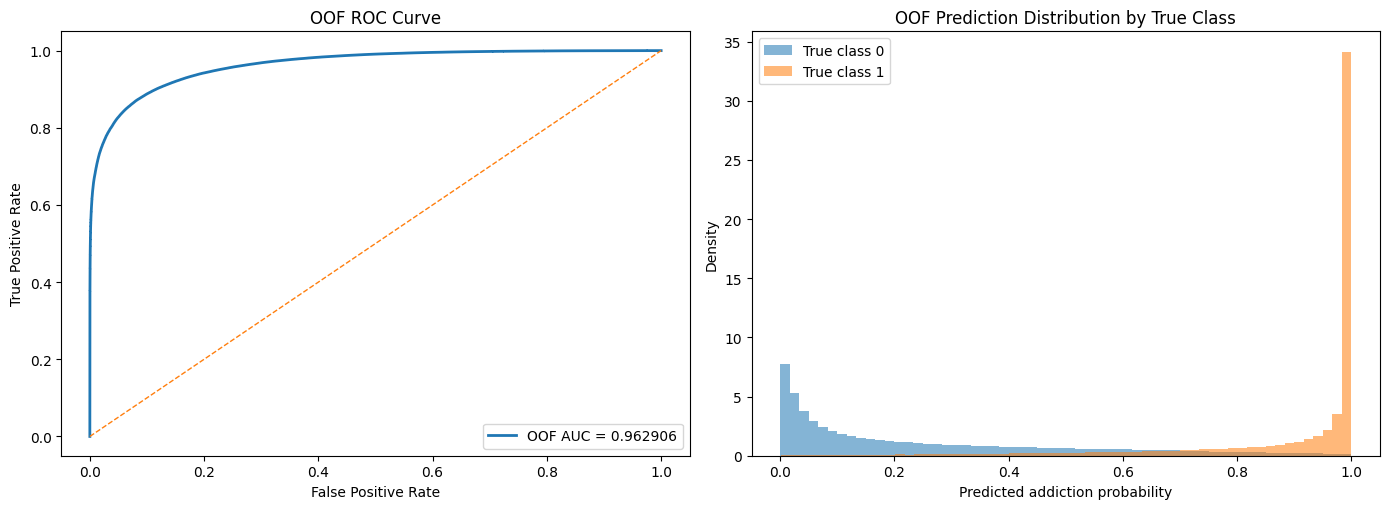

In [9]:
fpr, tpr, _ = roc_curve(y, oof_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].plot(fpr, tpr, linewidth=2, label=f'OOF AUC = {overall_oof_auc:.6f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('OOF ROC Curve')
axes[0].legend()

axes[1].hist(oof_pred[y.values == 0], bins=60, alpha=0.55, density=True, label='True class 0')
axes[1].hist(oof_pred[y.values == 1], bins=60, alpha=0.55, density=True, label='True class 1')
axes[1].set_xlabel('Predicted addiction probability')
axes[1].set_ylabel('Density')
axes[1].set_title('OOF Prediction Distribution by True Class')
axes[1].legend()

plt.tight_layout()
plt.show()


# 9. Watch CatBoost Learn 📈🐾

Boosting is like a team of cats taking turns fixing mistakes. 😸

- Tree 1 makes a rough guess.
- Tree 2 focuses on what tree 1 got wrong.
- Tree 3 corrects more mistakes.
- And so on.

The validation curves below show AUC as more trees are added. Early stopping protects us from endlessly adding trees after validation has stopped improving.


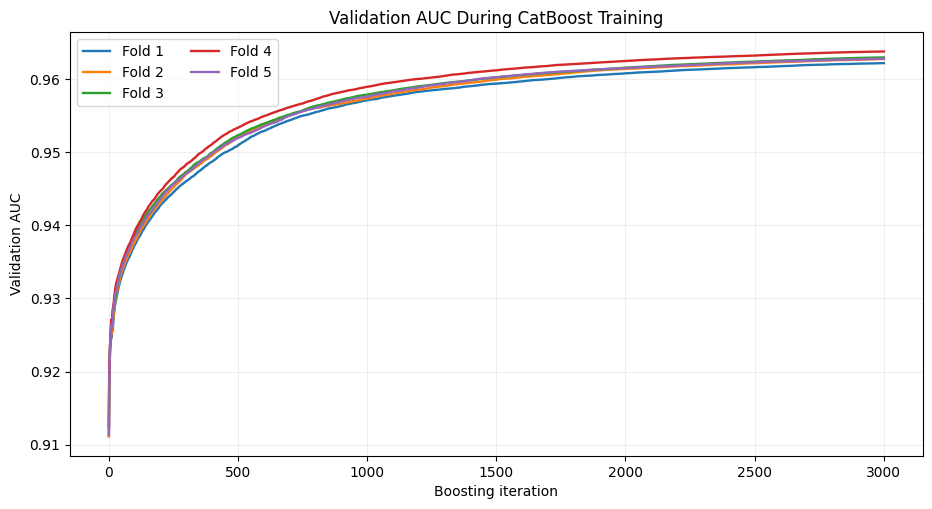

In [10]:
history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()

if not history_df.empty:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for fold, g in history_df.groupby('fold'):
        ax.plot(g['iteration'], g['val_auc'], linewidth=1.7, label=f'Fold {fold}')
    ax.set_xlabel('Boosting iteration')
    ax.set_ylabel('Validation AUC')
    ax.set_title('Validation AUC During CatBoost Training')
    ax.legend(ncol=2)
    ax.grid(alpha=0.2)
    plt.show()
else:
    print('No validation history was returned by this CatBoost build.')


# 10. Feature Importance 📊🐱

CatBoost's default classification importance is called **PredictionValuesChange**.

### What does that mean?

Imagine nudging a feature so the model walks down a different branch of a tree. CatBoost asks:

> “How much do predictions tend to change because this feature participates in those splits?”

Features that frequently create large prediction changes receive more importance.

This is **not the same definition as XGBoost gain**, so do not compare the numeric percentages as if they were the same currency. The ranking is still a great source of feature-engineering ideas.

We compute importance separately for all five fold models, normalize each fold to percentages, then average them.


In [11]:
importance_long = pd.concat(importance_frames, ignore_index=True)

# CatBoost normally returns percentages summing to ~100, but normalize explicitly
# so the saved artifact has a clear and stable interpretation.
importance_long['importance_pct'] = importance_long.groupby('fold')['importance_pct'].transform(
    lambda s: 100 * s / s.sum() if s.sum() > 0 else 0.0
)

feature_importance = (
    importance_long
    .groupby('feature', as_index=False)
    .agg(
        mean_importance_pct=('importance_pct', 'mean'),
        importance_pct_std=('importance_pct', 'std'),
    )
    .sort_values('mean_importance_pct', ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(25).style.format({
    'mean_importance_pct': '{:.2f}%',
    'importance_pct_std': '{:.2f}%',
}))


,feature,mean_importance_pct,importance_pct_std
0,weekend_screen_time,22.68%,0.40%
1,daily_screen_time_hours,20.56%,0.26%
2,notifications_per_day,12.60%,0.22%
3,app_opens_per_day,11.11%,0.18%
4,social_media_hours,10.81%,0.12%
5,social_share_of_daily,5.25%,0.09%
6,work_study_share_of_daily,3.20%,0.11%
7,gaming_share_of_daily,2.58%,0.11%
8,time_accounting_residual,1.94%,0.07%
9,work_study_hours,1.74%,0.18%


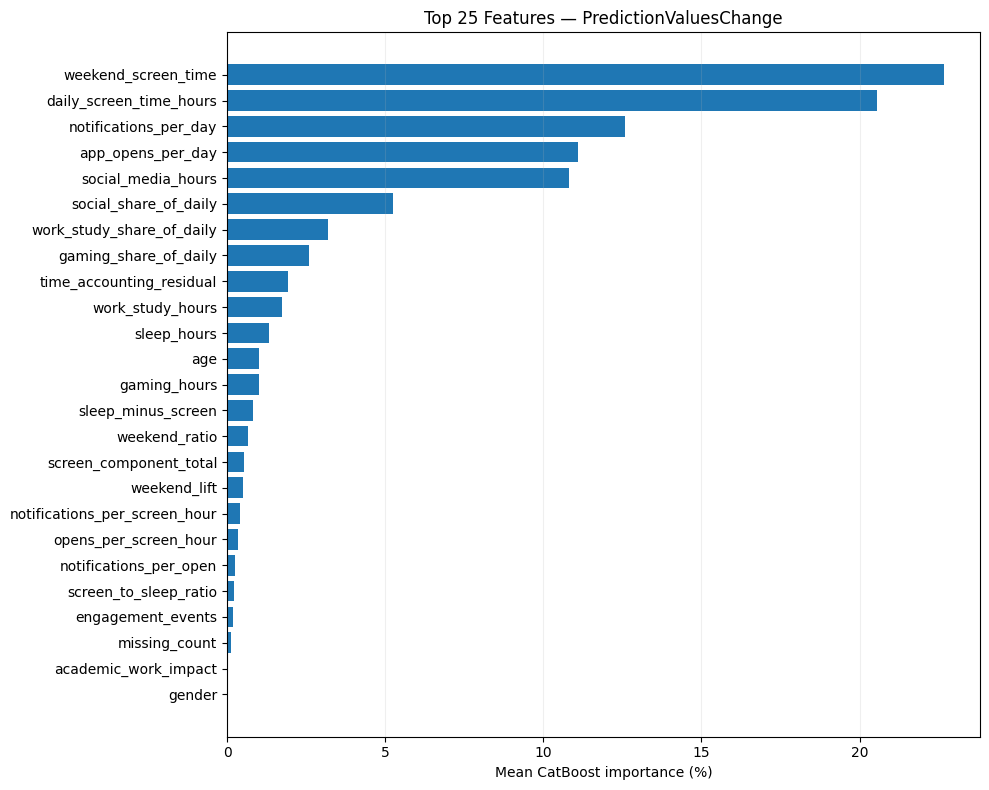

In [12]:
top_n = 25
plot_imp = feature_importance.head(top_n).sort_values('mean_importance_pct')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_imp['feature'], plot_imp['mean_importance_pct'])
ax.set_xlabel('Mean CatBoost importance (%)')
ax.set_title(f'Top {top_n} Features — PredictionValuesChange')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


## How should we use importance? 🕵️

Good uses:

- discover which raw signals dominate,
- spot engineered features that actually matter,
- generate interaction ideas,
- compare broad patterns across folds.

Bad use:

> “Feature #1 caused addiction.”

Feature importance is about **prediction**, not causation. A model finding a strong pattern does not prove that changing the feature would change the real-world outcome.


# 11. Save OOF Predictions + Metrics + Importance 💾

We save the same three reusable training artifacts as the XGB and NN starters:

- `oof_predictions.csv`
- `fold_metrics.csv`
- `feature_importance.csv`

That makes future blending pleasantly boring: load files, align by `id`, compare or combine predictions. 😎


In [13]:
oof_df = pd.DataFrame({
    ID_COL: train_ids,
    TARGET: y,
    'fold': fold_assignment,
    'oof_pred': oof_pred,
})

assert (oof_df['fold'] > 0).all()
assert oof_df['oof_pred'].between(0, 1).all()
assert oof_df['oof_pred'].notna().all()

oof_df.to_csv('oof_predictions.csv', index=False)
fold_metrics_df.to_csv('fold_metrics.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print('✅ Saved oof_predictions.csv')
print('✅ Saved fold_metrics.csv')
print('✅ Saved feature_importance.csv')
display(oof_df.head())


✅ Saved oof_predictions.csv
✅ Saved fold_metrics.csv
✅ Saved feature_importance.csv


,id,addicted_label,fold,oof_pred
0,0,1,4,0.759801
1,1,0,4,0.036157
2,2,0,4,0.404602
3,3,1,5,0.334376
4,4,1,3,0.999742


# 12. Make `submission.csv` 🚀

The test prediction is the **average of the five fold models**.

Why average them?

Each fold model saw a slightly different 80% training sample. Their small disagreements can cancel out, making the average a little more stable than trusting one cat alone. 🐱🐱🐱🐱🐱


In [14]:
if sample_submission is not None:
    submission = sample_submission.copy()
    assert ID_COL in submission.columns
    assert TARGET in submission.columns
    assert len(submission) == len(test)
    assert np.array_equal(submission[ID_COL].values, test_ids.values)
    submission[TARGET] = test_pred
else:
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred})

assert submission[TARGET].between(0, 1).all()
assert submission[TARGET].notna().all()

submission.to_csv('submission.csv', index=False)

print('🚀 Saved submission.csv')
print('Prediction mean:', f"{submission[TARGET].mean():.5f}")
print('Prediction min :', f"{submission[TARGET].min():.5f}")
print('Prediction max :', f"{submission[TARGET].max():.5f}")
display(submission.head(10))


🚀 Saved submission.csv
Prediction mean: 0.70937
Prediction min : 0.00022
Prediction max : 1.00000


,id,addicted_label
0,691369,0.999374
1,691370,0.943146
2,691371,0.958682
3,691372,0.982887
4,691373,0.997710
5,691374,0.898414
6,691375,0.898306
7,691376,0.602089
8,691377,0.978792
9,691378,0.297996


# 13. Mission Complete! 🐱🚀✨

You now have the same four core artifacts as the earlier starters:

- **`submission.csv`** — average test probabilities from five CatBoost folds
- **`oof_predictions.csv`** — honest training predictions + fold assignment
- **`fold_metrics.csv`** — per-fold AUC, best iteration, timing
- **`feature_importance.csv`** — fold-averaged CatBoost PredictionValuesChange importance

## Fun next experiments 💡

### 1. CatBoost vs XGBoost vs NN
Load the three OOF files and compare:

- AUC,
- prediction correlation,
- where the models disagree.

A slightly weaker model can still be a fantastic ensemble partner if it makes **different mistakes**.

### 2. Raw categories vs engineered categories
Try combinations such as:

- `stress_level × academic_work_impact`
- binned screen time × stress
- gender × weekend lift bins

CatBoost is a natural playground for categorical interactions.

### 3. Hyperparameter safari 🐾
Try modest changes to:

- `depth`
- `learning_rate`
- `l2_leaf_reg`
- `random_strength`
- `bagging_temperature`

Change **one idea at a time** and trust OOF CV more than vibes.

### 4. Build the Model Olympics 🏆
This notebook is now another contestant for the future ensemble notebook:

**XGBoost 🌲 + PyTorch 🧠 + CatBoost 🐱**

The leaderboard may reward the best model, but Kaggle often rewards the best **team of models**.

---

### Final rule of CatBoost Club

> **Keep categories categorical, validate honestly, save your OOFs, and always give the cat enough boosting rounds.** 😺

Happy Kaggleing! 🏆🚀
